# Quick Start – How to Run This Notebook

This notebook implements an AI-based network anomaly detection pipeline using supervised and unsupervised machine learning models.

## Steps to Run
1. Run the notebook cells from top to bottom.
2. When prompted, select the input CSV file containing the network monitoring data.
   - The loader supports Google Colab upload, a graphical file picker, or manual file path input.
3. Once the dataset is loaded, the notebook will automatically:
   - Perform data preprocessing and feature engineering
   - Conduct exploratory data analysis (EDA)
   - Train and evaluate multiple anomaly detection models
   - Display performance metrics and visualizations

## Notes
- The dataset used in this project is synthetic and provided for academic purposes.
- No manual configuration is required beyond selecting the input CSV file.


Saving nagios_network_traffic (1).csv to nagios_network_traffic (1) (1).csv
Loaded file from Colab upload: nagios_network_traffic (1) (1).csv
Shape: (5000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      5000 non-null   datetime64[ns]
 1   host           5000 non-null   object        
 2   traffic_in     5000 non-null   float64       
 3   traffic_out    5000 non-null   float64       
 4   latency_ms     5000 non-null   float64       
 5   packet_loss    5000 non-null   float64       
 6   service_state  5000 non-null   int64         
 7   anomaly_flag   5000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 312.6+ KB
None
                           timestamp   traffic_in  traffic_out   latency_ms  \
count                           5000  5000.000000  5000.00

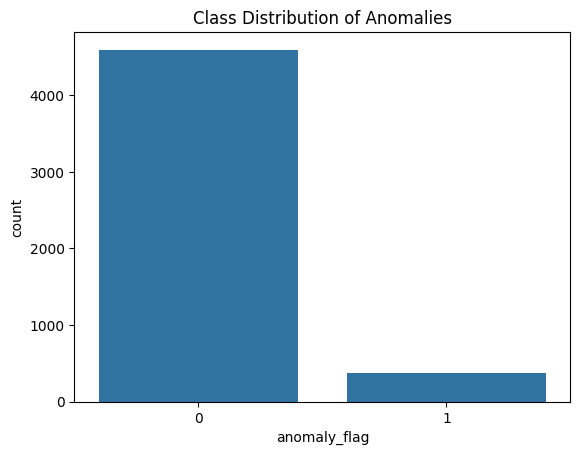

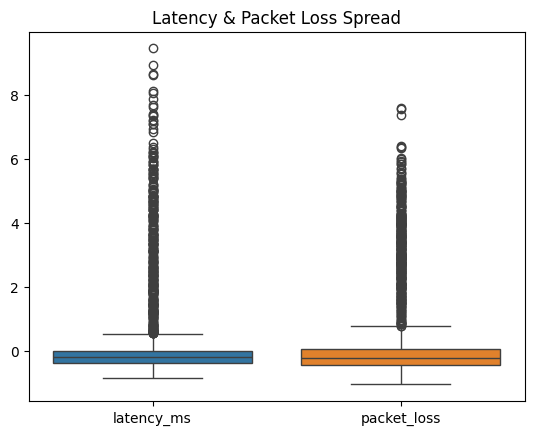

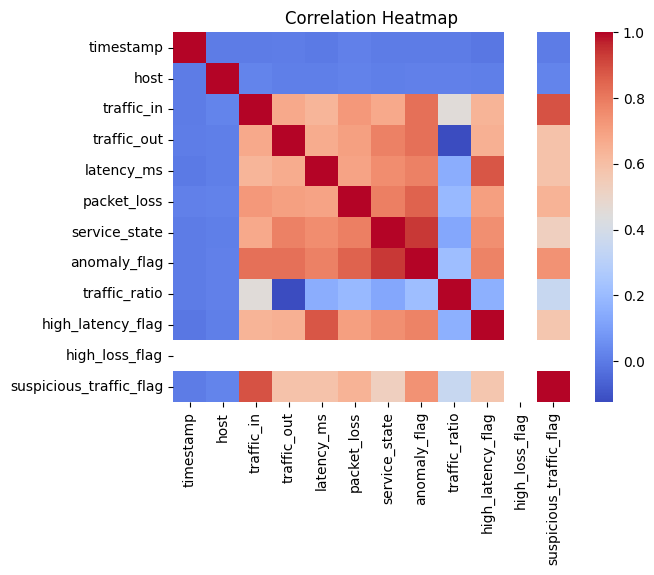

Training size: (3726, 10)
Test size: (1243, 10)
Baseline Accuracy: 1.0
Baseline Precision: 1.0
Baseline Recall: 1.0
Baseline F1 Score: 1.0


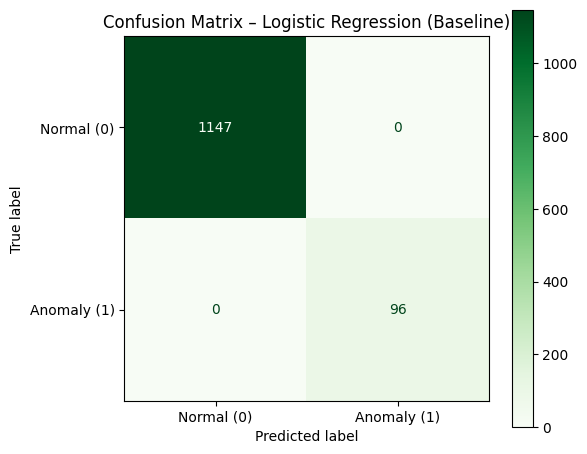

Isolation Forest Accuracy: 0.99597747385358
Isolation Forest Precision: 0.9504950495049505
Isolation Forest Recall: 1.0
Isolation Forest F1: 0.9746192893401016


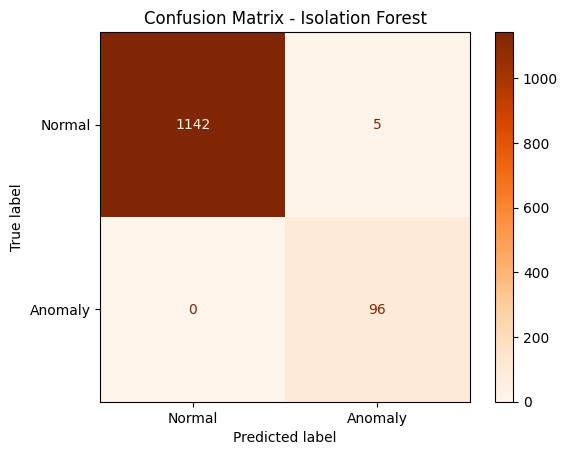

Model training complete.
Accuracy : 1.0
Precision:
 1.0
Recall   :
 1.0
F1 Score :
 1.0

Confusion Matrix:
 [[1147    0]
 [   0   96]]


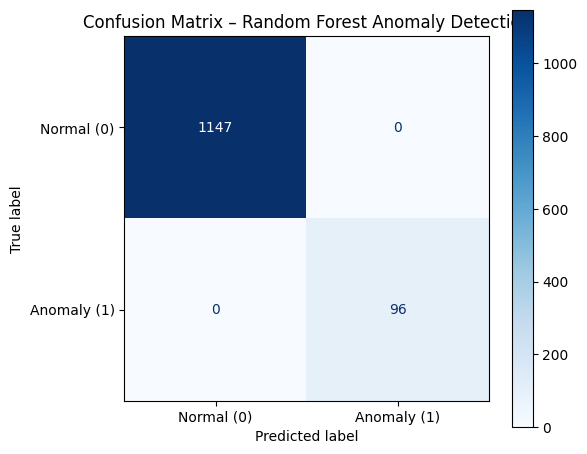

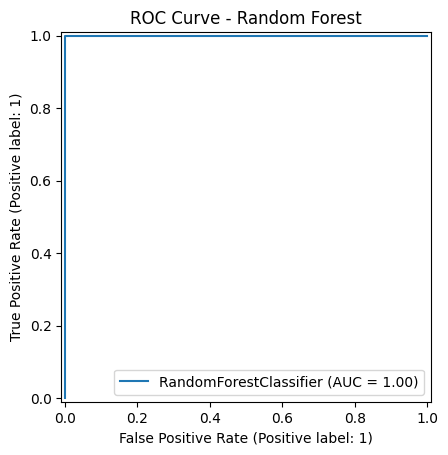

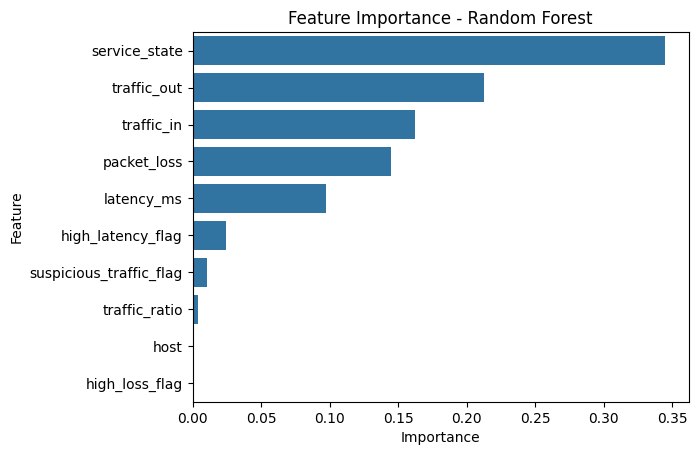

Model saved as random_forest_anomaly_detector.pkl


,pred
host,
0,0.075949
1,0.080537
2,0.083333
3,0.040000
4,0.071942
5,0.096296
6,0.092857
7,0.079137
8,0.060403


In [13]:
import pandas as pd


# NOTE: This notebook will prompt the user to select the input CSV file before execution proceeds.

## NEW DATA EXTRACTOR - PROMPT FOR THE FILE
## PLEASE GO TO THE BOTTOM AND CLIKC BUTTON TO ADD THE CSV FILE
### THIS DATA EXTRACTOR PROMPTS FOR THE FILE VIA
  ### 1. GOOGLE COLLAB (FILE PICKER AND UPLOADER)
  ### 2. GUI FILE PICKER (IF SUPPORTED)
  ### 3. CLI FILE PICKER (AS FALLBACK)

import sys
import os

def load_csv_universal():
    """
    Attempts to load a CSV file using:
    1) Google Colab file upload (if in Colab)
    2) GUI file picker (tkinter)
    3) CLI prompt fallback
    """

    # ---- 1. Google Colab ----
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            print(f"Loaded file from Colab upload: {filename}")
            return pd.read_csv(filename)
    except Exception:
        pass

    # ---- 2. GUI file picker ----
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()

        file_path = filedialog.askopenfilename(
            title="Select CSV file",
            filetypes=[("CSV files", "*.csv")]
        )

        if file_path:
            print(f"Loaded file from GUI: {file_path}")
            return pd.read_csv(file_path)
    except Exception:
        pass

    # ---- 3. CLI fallback ----
    file_path = input("Enter full path to CSV file: ").strip()

    if not os.path.isfile(file_path):
        raise FileNotFoundError("Invalid file path provided.")

    print(f"Loaded file from CLI path: {file_path}")
    return pd.read_csv(file_path)


# ===== Load dataset =====
df = load_csv_universal()

# Convert timestamp column
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
else:
    raise KeyError("Expected column 'timestamp' not found in CSV.")

print("Shape:", df.shape)
df.head()


## NEW DATA EXTRACTOR - PROMPT FOR THE FILE - END

## OLD DATA EXTRACTOR
##    df = pd.read_csv("/content/sample_data/nagios_network_traffic (1).csv")
##    df["timestamp"] = pd.to_datetime(df["timestamp"])
## OLD DATA EXTRACTOR- END

## print("Shape:", df.shape)
## print(df.head())
print(df.info())
print(df.describe())

# Remove duplicate records
df = df.drop_duplicates()

# Remove invalid negative values
df = df[
    (df["traffic_in"] >= 0) &
    (df["traffic_out"] >= 0) &
    (df["latency_ms"] >= 0)
]

# Check for missing values
print(df.isnull().sum())

df["traffic_ratio"] = df["traffic_in"] / (df["traffic_out"] + 1)  # avoid /0
df["high_latency_flag"] = (df["latency_ms"] > 100).astype(int)
df["high_loss_flag"] = (df["packet_loss"] > 10).astype(int)
df["suspicious_traffic_flag"] = (df["traffic_in"] > 300).astype(int)

from sklearn.preprocessing import StandardScaler

# Encode host device name
df["host"] = df["host"].astype("category").cat.codes

# Scale numeric features
scale_cols = ["traffic_in","traffic_out","latency_ms","packet_loss","traffic_ratio"]
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

X = df.drop(["anomaly_flag","timestamp"], axis=1)
y = df["anomaly_flag"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution of Anomalies")
plt.show()

sns.boxplot(data=df[["latency_ms","packet_loss"]])
plt.title("Latency & Packet Loss Spread")
plt.show()

sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# COMPARE NORMAL VS ANOMALOUS LOGS
# Compare normal vs anomalous logs
df.groupby("anomaly_flag")[[
    "traffic_in",
    "traffic_out",
    "latency_ms",
    "packet_loss"
]].mean()

# COMPARE NORMAL VS ANOMALOUS LOGS- END

# Split data into training and testing sets (moved before model training)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline Precision:", precision_score(y_test, baseline_pred))
print("Baseline Recall:", recall_score(y_test, baseline_pred))
print("Baseline F1 Score:", f1_score(y_test, baseline_pred))

## BASELINE CONFUSION MATRIX
# Confusion Matrix – Logistic Regression (Baseline)
cm_base = confusion_matrix(y_test, baseline_pred)

disp_base = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=["Normal (0)", "Anomaly (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp_base.plot(ax=ax, cmap="Greens", values_format="d")

plt.title("Confusion Matrix – Logistic Regression (Baseline)")
plt.grid(False)
plt.tight_layout()
plt.show()

## BASELINE CONFUSION MATRIX -END

#STEP 4 UNSUPERVISED MODEL  - ISOLATION FOREST
# STEP 4 - UNSUPERVISED MODEL: ISOLATION FOREST
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.08,  # matches anomaly rate
    random_state=42
)

# Train on features only (unsupervised)
iso_model.fit(X_train)

# Predict anomalies (-1 = anomaly, 1 = normal)
iso_preds = iso_model.predict(X_test)

# Convert to binary (1 = anomaly, 0 = normal)
iso_preds = (iso_preds == -1).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Isolation Forest Accuracy:", accuracy_score(y_test, iso_preds))
print("Isolation Forest Precision:", precision_score(y_test, iso_preds))
print("Isolation Forest Recall:", recall_score(y_test, iso_preds))
print("Isolation Forest F1:", f1_score(y_test, iso_preds))

## ISOLATION FOREST CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Isolation Forest
iso_cm = confusion_matrix(y_test, iso_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=iso_cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(cmap="Oranges")
plt.title("Confusion Matrix - Isolation Forest")
plt.show()

## ISOLATION FOREST CONFUSION MATRIX

#STEP 4 UNSUPERVISED MODEL  - ISOLATION FOREST - END


#LOGISTIC REGRESSION- END

# STEp 4- RANDOM FOREST MODEL

# Train the Random forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
print("Model training complete.")

#Make predictions and evaluate
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:\n", precision)
print("Recall   :\n", recall)
print("F1 Score :\n", f1)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

#-----CONFUSION MATRIX PLOT
# --- Visual Confusion Matrix (for report & presentation) ---

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Anomaly (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Confusion Matrix – Random Forest Anomaly Detection")
plt.grid(False)
plt.tight_layout()
plt.show()

#-----CONFUSION MATRIX PLOT END

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

#Feature importance
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})

fi_df.sort_values("Importance", ascending=False, inplace=True)

sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

#save the model for future deployments
import joblib

##joblib.dump(model, "AlfredoTirante_anomaly_detector.pkl")

##Insert add
joblib.dump(
    {
        "model": model,
        "scaler": scaler,
        "features": X.columns.tolist(),
        "scale_cols": scale_cols
    },
    "anomaly_detector_bundle.pkl"
)
##Insert add

print("Model saved as random_forest_anomaly_detector.pkl")
# STEp 4- RANDOM FOREST MODEL -END

# STEP 5 - Critical Thinking → Ethical AI & Bias Auditing

# 5.1 Explainability & Decision Transparency

# Show most influential features
fi_df.head(10)

#5.5 Bias audit by Device Category
import numpy as np

df["pred"] = model.predict(X)
group_accuracy = df.groupby("host")["pred"].mean()

group_accuracy.head(10)

# STEP 5 - Critical Thinking → Ethical AI & Bias Auditing - END

## Standalone Execution

The trained model produced in this notebook can be executed outside
of Google Colab using the companion Python script:

**run_anomaly_detector.py**

### Usage
```bash
python run_anomaly_detector.py
